# Lab 1. Missing values and correlations

Кратко: генерация данных → EDA/визуализации → пропуски MCAR/MNAR → импутация → корреляции / UpSet.


In [ ]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Локальные модули визуализации лежат на уровене
sys.path.insert(0, str(Path.cwd().parent))
import pairScatterPlotFunc
import raincloudPlotFunc
import upSetPlotFunc

# reload — чтобы правки .py подхватывались без перезапуска ядра
importlib.reload(raincloudPlotFunc)
importlib.reload(pairScatterPlotFunc)
importlib.reload(upSetPlotFunc)
from pairScatterPlotFunc import pair_scatter_dataset_panel, pair_scatter_plot
from raincloudPlotFunc import raincloud_plot
from upSetPlotFunc import upset_plot


### [1.1] Generate and fixate `dfS00`

Синтетический датасет: 4 признака, 1 класс, корреляция A–B = 0.9.


In [2]:
# Параметры генерации (фиксируем seed для воспроизводимости)
RANDOM_STATE = 42
N_OBJECTS = 1000
FEATURES = ("A", "B", "C", "D")
CLASS_LABEL = 0
R_AB = 0.9  # целевая корреляция только для пары A–B

LAB_DIR = Path.cwd()
OUT_PATH = LAB_DIR / "dfS00.csv"

def build_covariance(r_ab: float) -> np.ndarray:
    """Ковариация 4×4: дисперсии = 1, значит cov(A,B) = корреляция."""
    cov = np.eye(len(FEATURES))
    cov[0, 1] = r_ab
    cov[1, 0] = r_ab
    return cov


def generate_dfS00(random_state: int = RANDOM_STATE) -> pd.DataFrame:
    # Многомерное нормальное: остальные пары признаков почти независимы
    mean = np.zeros(len(FEATURES))
    cov = build_covariance(R_AB)
    rng = np.random.RandomState(random_state)
    values = rng.multivariate_normal(mean=mean, cov=cov, size=N_OBJECTS)
    frame = pd.DataFrame(values, columns=list(FEATURES))
    frame["class"] = CLASS_LABEL
    return frame


dfS00 = generate_dfS00()
dfS00.to_csv(OUT_PATH, index=False)  # фиксация выборки на диск
print(f"saved {OUT_PATH}  shape={dfS00.shape}")


saved c:\Users\Nexxa\Documents\Programming\Statistics\lab1\dfS00.csv  shape=(1000, 5)


### [1.2] Dataset statistics

Таблицы: размерность, типы, классы, описательные статистики, NaN и нули.


In [3]:
# Список количественных признаков (без class)
feature_cols = list(FEATURES)

# Размерность датасета
shape_table = pd.DataFrame(
    {
        "n_objects": [dfS00.shape[0]],
        "n_columns": [dfS00.shape[1]],
        "n_features": [len(feature_cols)],
        "n_classes": [dfS00["class"].nunique()],
    },
    index=["dfS00"],
)

# Типы столбцов + роль (feature / class)
dtype_table = (
    dfS00.dtypes.rename("dtype")
    .astype(str)
    .to_frame()
    .assign(role=lambda t: ["feature" if c in feature_cols else "class" for c in t.index])
)

# Число объектов в каждом классе
class_table = (
    dfS00["class"]
    .value_counts()
    .sort_index()
    .rename("n_objects")
    .to_frame()
)
class_table.index.name = "class"

# Описательные статистики (+ IQR и range ниже)
sample_stats = dfS00[feature_cols].agg(
    [
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max",
        "skew",
    ]
)
sample_stats.loc["IQR"] = dfS00[feature_cols].quantile(0.75) - dfS00[feature_cols].quantile(0.25)
sample_stats.loc["range"] = dfS00[feature_cols].max() - dfS00[feature_cols].min()

# Сколько объектов имеют хотя бы один NaN / хотя бы один ноль
nan_by_class = (
    dfS00.groupby("class")[feature_cols]
    .apply(lambda g: g.isna().any(axis=1).sum())
    .rename("objects_with_nan")
    .to_frame()
)
zero_by_class = (
    dfS00.groupby("class")[feature_cols]
    .apply(lambda g: (g == 0).any(axis=1).sum())
    .rename("objects_with_zero")
    .to_frame()
)

# Счётчики NaN и точных нулей по признакам внутри класса
nan_cells_by_class = dfS00.groupby("class")[feature_cols].apply(lambda g: g.isna().sum())
zero_cells_by_class = dfS00.groupby("class")[feature_cols].apply(lambda g: (g == 0).sum())

print("Dimensionality")
display(shape_table)
print("Column types")
display(dtype_table)
print("Classes")
display(class_table)
print("Sample estimates (features)")
display(sample_stats.round(4))
print("Objects with at least one NaN, by class")
display(nan_by_class)
print("Objects with at least one exact 0, by class")
display(zero_by_class)
print("NaN cell counts per feature, by class")
display(nan_cells_by_class)
print("Exact-0 cell counts per feature, by class")
display(zero_cells_by_class)


Dimensionality


,n_objects,n_columns,n_features,n_classes
dfS00,1000,5,4,1


Column types


,dtype,role
A,float64,feature
B,float64,feature
C,float64,feature
D,float64,feature
class,int64,class


Classes


...

,objects_with_zero
class,
0,0


NaN cell counts per feature, by class


,A,B,C,D
class,,,,
0,0,0,0,0


Exact-0 cell counts per feature, by class


,A,B,C,D
class,,,,
0,0,0,0,0


### [1.3] 1D raincloud + boxplot

По каждому признаку: jitter (rain) + box (median/IQR/range) + KDE (cloud).


features: n=1000  median=-0.0388  IQR=[-0.6571, 0.6000]  range=[-3.1372, 3.1981]
features: n=1000  median=-0.0319  IQR=[-0.6927, 0.6000]  range=[-3.1848, 3.2201]
features: n=1000  median=-0.0075  IQR=[-0.6753, 0.6423]  range=[-3.2413, 3.1521]
features: n=1000  median=0.0202  IQR=[-0.6770, 0.6939]  range=[-2.8963, 3.8527]


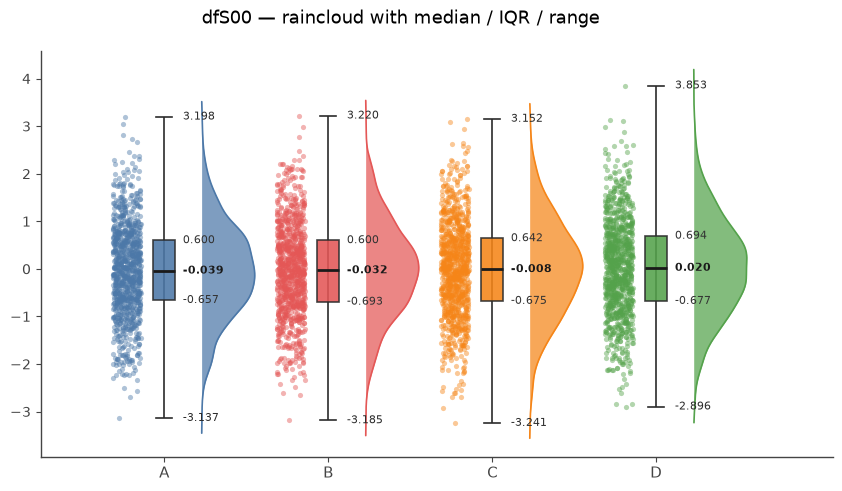

In [4]:
# 1D raincloud: точки + box (можно сменить center/box/whiskers) + плотность
rain = raincloud_plot(
    dfS00,
    columns=feature_cols,
    orientation="vertical",
    center="median",
    box="iqr",
    whiskers="range",
    title="dfS00 — raincloud with median / IQR / range",
)
for (feature, group), est in rain.estimates.items():
    print(f"{feature}: n={est.n}  median={est.center:.4f}  IQR=[{est.box_low:.4f}, {est.box_high:.4f}]  range=[{est.whisker_low:.4f}, {est.whisker_high:.4f}]")


### [1.4] 2D pairwise scatter + class densities

Все пары признаков: scatter + маргинальные плотности (свой модуль `pair_scatter_plot`).


pairs: (('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'D'))
classes: ('0',)


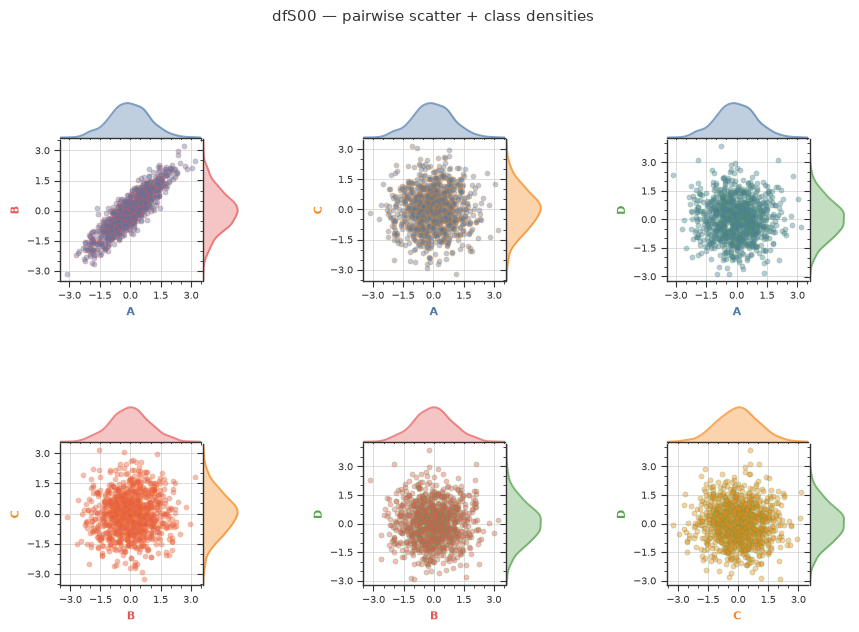

In [5]:
# Общая палитра с raincloud / UpSet
PAIR_PALETTE = [
    "#4C78A8",
    "#E45756",
    "#F58518",
    "#54A24B",
    "#B279A2",
    "#72B7B2",
    "#ECAE3E",
    "#9D755D",
]

# Все пары признаков: scatter + плотности по осям
pair = pair_scatter_plot(
    dfS00,
    columns=feature_cols,
    group="class",
    title="dfS00 — pairwise scatter + class densities",
    show_title=True,
    show_legend=False,
    show_scatter=True,
    show_density=True,
    square=True,
    palette=PAIR_PALETTE,
    point_alpha=0.40,
    density_alpha=0.35,
    show_grid=True,
    major_tick_count=5,
    minor_tick_count=2,
    axis_color="#333333",
    axis_linewidth=1.0,
)
print(f"pairs: {pair.pairs}")
print(f"classes: {pair.groups}")


### [1.5] Pearson & Spearman correlation heatmaps

Сопряжённость признаков на всём датасете и внутри каждого класса.


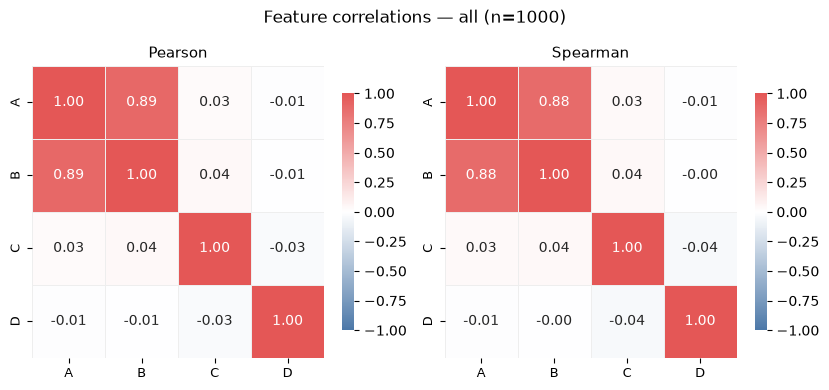

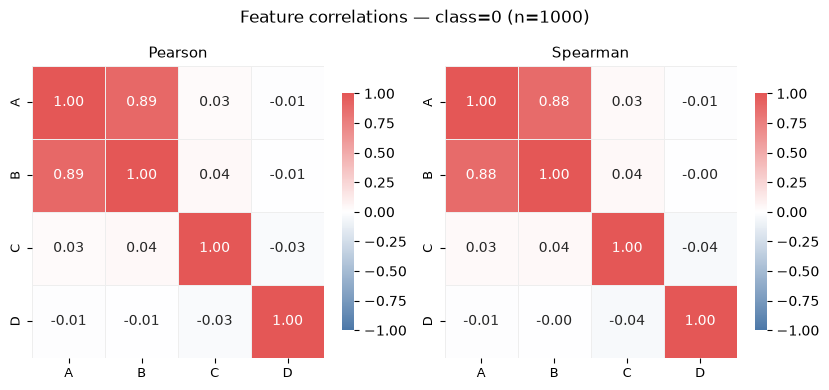


=== all ===

Pearson


,A,B,C,D
A,1.0000,0.8914,0.0294,-0.0090
B,0.8914,1.0000,0.0448,-0.0068
C,0.0294,0.0448,1.0000,-0.0324
D,-0.0090,-0.0068,-0.0324,1.0000



Spearman


,A,B,C,D
A,1.0000,0.8762,0.0322,-0.0120
B,0.8762,1.0000,0.0434,-0.0015
C,0.0322,0.0434,1.0000,-0.0418
D,-0.0120,-0.0015,-0.0418,1.0000



=== class=0 ===

Pearson


,A,B,C,D
A,1.0000,0.8914,0.0294,-0.0090
B,0.8914,1.0000,0.0448,-0.0068
C,0.0294,0.0448,1.0000,-0.0324
D,-0.0090,-0.0068,-0.0324,1.0000



Spearman


,A,B,C,D
A,1.0000,0.8762,0.0322,-0.0120
B,0.8762,1.0000,0.0434,-0.0015
C,0.0322,0.0434,1.0000,-0.0418
D,-0.0120,-0.0015,-0.0418,1.0000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Расходящаяся шкала из тех же цветов, что raincloud/UpSet
CORR_CMAP = LinearSegmentedColormap.from_list(
    "pair_div",
    ["#4C78A8", "#FFFFFF", "#E45756"],
)


def correlation_heatmaps(
    data: pd.DataFrame,
    columns: list[str],
    *,
    group: str = "class",
    methods: tuple[str, ...] = ("pearson", "spearman"),
    annot: bool = True,
    fmt: str = ".2f",
    cmap=CORR_CMAP,
    figsize_panel: tuple[float, float] = (4.2, 3.6),
) -> dict[str, dict[str, pd.DataFrame]]:
    """Heatmap Пирсона/Спирмена: весь датасет и каждый класс отдельно."""
    # Сначала весь датасет, затем срезы по class
    scopes: list[tuple[str, pd.DataFrame]] = [("all", data)]
    if group in data.columns:
        for label, part in data.groupby(group, sort=True):
            scopes.append((f"class={label}", part))

    results: dict[str, dict[str, pd.DataFrame]] = {}
    for scope_name, frame in scopes:
        results[scope_name] = {}
        n_methods = len(methods)
        fig_w = figsize_panel[0] * n_methods
        fig_h = figsize_panel[1]
        fig, axes = plt.subplots(
            1,
            n_methods,
            figsize=(fig_w, fig_h),
            squeeze=False,
        )
        fig.suptitle(
            f"Feature correlations — {scope_name} (n={len(frame)})",
            fontsize=12,
            y=1.02,
        )
        for ax, method in zip(axes[0], methods):
            corr = frame[columns].corr(method=method)
            results[scope_name][method] = corr
            sns.heatmap(
                corr,
                ax=ax,
                annot=annot,
                fmt=fmt,
                cmap=cmap,
                vmin=-1,
                vmax=1,
                center=0,
                square=True,
                cbar_kws={"shrink": 0.8},
                linewidths=0.5,
                linecolor="#EEEEEE",
            )
            ax.set_title(method.capitalize(), fontsize=11)
            ax.tick_params(axis="both", labelsize=9)
        fig.tight_layout()
        display(fig)
        plt.close(fig)

    return results


# Рисуем heatmap и сохраняем матрицы
corr_maps = correlation_heatmaps(dfS00, feature_cols, group="class")

# Те же матрицы числами (для отчёта)
for scope, by_method in corr_maps.items():
    print(f"\n=== {scope} ===")
    for method, mat in by_method.items():
        print(f"\n{method.capitalize()}")
        display(mat.round(4))


### [1.6] Clone `dfSdXX` with random missing cells + scatter panel

MCAR: случайно выбиваем долю ячеек признаков → клоны `dfSd00`…`dfSd80`, панно scatter для выбранной пары.

From `dfS00`, build clones where a user-chosen fraction of **feature** cells
is set to NaN (MCAR). Rates: 0%, 1%, 2%, 5%, 10%, 20%, 50%, 80%.
Then plot a chosen feature pair (default **A+B**) as an m×n scatter panel,
one subplot per clone.


,missing_rate_target,nan_cells,nan_frac,complete_rows
name,,,,
dfSd00,0.00,0,0.00,1000
dfSd01,0.01,40,0.01,960
dfSd02,0.02,80,0.02,924
dfSd05,0.05,200,0.05,810
dfSd10,0.10,400,0.10,663
dfSd20,0.20,800,0.20,418
dfSd50,0.50,2000,0.50,73
dfSd80,0.80,3200,0.80,2


clones: ['dfSd00', 'dfSd01', 'dfSd02', 'dfSd05', 'dfSd10', 'dfSd20', 'dfSd50', 'dfSd80']


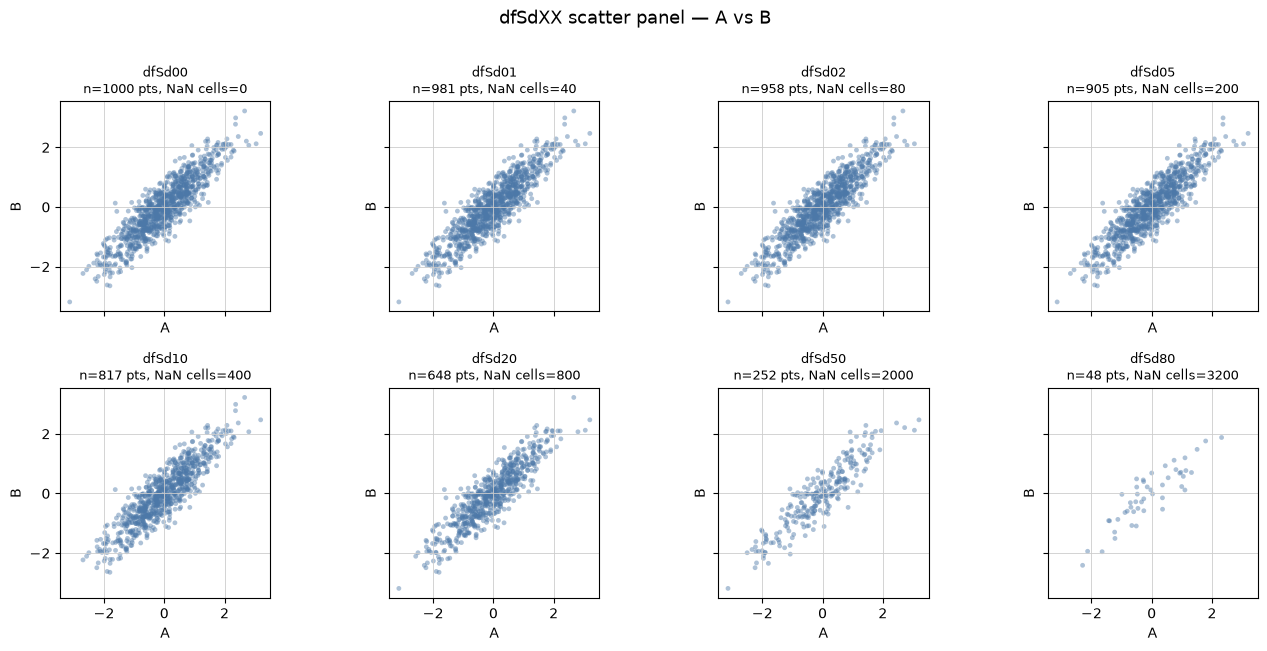

In [7]:
import numpy as np
import pandas as pd
from IPython.display import display

# --- параметры (можно менять) ---
# Доли MCAR-пропусков и пара признаков для панно
MISSING_RATES = (0.00, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 0.80)
PAIR_XY = ("A", "B")  # feature pair for the scatter panel
MISSING_SEED = RANDOM_STATE
PANEL_NCOLS = 4

PAIR_PALETTE = globals().get(
    "PAIR_PALETTE",
    [
        "#4C78A8",
        "#E45756",
        "#F58518",
        "#54A24B",
        "#B279A2",
        "#72B7B2",
        "#ECAE3E",
        "#9D755D",
    ],
)


def _rate_tag(rate: float) -> str:
    pct = round(rate * 100)
    return f"{pct:02d}"


def punch_missing(
    data: pd.DataFrame,
    rate: float,
    *,
    columns: list[str] | None = None,
    random_state: int = 0,
) -> pd.DataFrame:
    """Копия датасета: случайно зануляем долю ячеек признаков (MCAR)."""
    out = data.copy()
    cols = list(columns) if columns is not None else [
        c for c in out.columns if c != "class"
    ]
    if rate <= 0:
        return out
    if rate > 1:
        raise ValueError("rate must be in [0, 1]")

    rng = np.random.default_rng(random_state)
    n_rows, n_cols = len(out), len(cols)
    n_cells = n_rows * n_cols
    n_drop = round(n_cells * rate)
    flat = rng.choice(n_cells, size=n_drop, replace=False)
    row_idx, col_idx = np.unravel_index(flat, (n_rows, n_cols))
    for r, c in zip(row_idx, col_idx):
        out.iat[int(r), out.columns.get_loc(cols[int(c)])] = np.nan
    return out


def clone_missing_datasets(
    data: pd.DataFrame,
    rates: tuple[float, ...] = MISSING_RATES,
    *,
    columns: list[str] | None = None,
    random_state: int = MISSING_SEED,
) -> dict[str, pd.DataFrame]:
    """Набор клонов dfSdXX с разной долей пропусков."""
    clones: dict[str, pd.DataFrame] = {}
    for i, rate in enumerate(rates):
        name = f"dfSd{_rate_tag(rate)}"
        clones[name] = punch_missing(
            data,
            rate,
            columns=columns,
            random_state=random_state + i,
        )
    return clones

# Визуализация выбранной пары по всем уровням пропусков
def scatter_missing_panel(
    clones: dict[str, pd.DataFrame],
    x: str,
    y: str,
    *,
    group: str = "class",
    feature_columns: list[str] | None = None,
    palette: list[str] | None = None,
    ncols: int = PANEL_NCOLS,
    point_alpha: float = 0.45,
    point_size: float = 12,
    title: str | None = None,
) -> None:
    """m×n scatter panel: one subplot per clone (shown once)."""
    names = list(clones.keys())
    n = len(names)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    colors = palette or PAIR_PALETTE
    feat_cols = feature_columns or feature_cols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.4 * ncols, 3.2 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    if title is None:
        title = f"scatter panel — {x} vs {y}"
    fig.suptitle(title, fontsize=13, y=1.01)

    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        frame = clones[name]
        plot_df = frame[[x, y, group]].dropna()
        classes = list(dict.fromkeys(plot_df[group].astype(str)))
        for j, cls in enumerate(classes):
            mask = plot_df[group].astype(str) == cls
            ax.scatter(
                plot_df.loc[mask, x],
                plot_df.loc[mask, y],
                s=point_size,
                c=colors[j % len(colors)],
                alpha=point_alpha,
                edgecolors="none",
                label=cls,
            )
        n_pair = len(plot_df)
        n_nan_cells = int(frame[feat_cols].isna().sum().sum())
        ax.set_title(f"{name}\nn={n_pair} pts, NaN cells={n_nan_cells}", fontsize=9)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(True, color="#CCCCCC", lw=0.6)
        ax.set_box_aspect(1)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_axis_off()

    fig.tight_layout()
    display(fig)
    plt.close(fig)


# Строим клоны и кладём dfSd00, dfSd01, … в globals()
dfSd_clones = clone_missing_datasets(
    dfS00,
    MISSING_RATES,
    columns=feature_cols,
    random_state=MISSING_SEED,
)
globals().update(dfSd_clones)

# Сводка: сколько NaN реально получилось
summary = pd.DataFrame(
    [
        {
            "name": name,
            "missing_rate_target": rate,
            "nan_cells": int(frame[feature_cols].isna().sum().sum()),
            "nan_frac": float(frame[feature_cols].isna().mean().mean()),
            "complete_rows": int((~frame[feature_cols].isna().any(axis=1)).sum()),
        }
        for name, rate, frame in zip(
            dfSd_clones.keys(), MISSING_RATES, dfSd_clones.values()
        )
    ]
).set_index("name")
display(summary.round(4))
print("clones:", list(dfSd_clones.keys()))

scatter_missing_panel(
    dfSd_clones,
    PAIR_XY[0],
    PAIR_XY[1],
    palette=PAIR_PALETTE,
    ncols=PANEL_NCOLS,
    title=f"dfSdXX scatter panel — {PAIR_XY[0]} vs {PAIR_XY[1]}",
)


### [1.7] Median-imputed `dfSdXXmed` + scatter panel + Pearson heatmaps

Заполнение пропусков медианой столбца; снова scatter-панно и heatmap Пирсона.

For each `dfSdXX`, fill feature NaNs with the **column median** → `dfSdXXmed`.
Then:
- m×n scatter panel for the chosen pair (default A+B)
- Pearson correlation heatmaps per imputed dataset (same style as [1.5])


,nan_cells_after,A_median,B_median
name,,,
dfSd00med,0,-0.0388,-0.0319
dfSd01med,0,-0.0388,-0.0355
dfSd02med,0,-0.0361,-0.0299
dfSd05med,0,-0.0399,-0.0248
dfSd10med,0,-0.0343,-0.0338
dfSd20med,0,-0.0388,-0.0367
dfSd50med,0,-0.0950,-0.0121
dfSd80med,0,-0.0388,-0.0266


median clones: ['dfSd00med', 'dfSd01med', 'dfSd02med', 'dfSd05med', 'dfSd10med', 'dfSd20med', 'dfSd50med', 'dfSd80med']


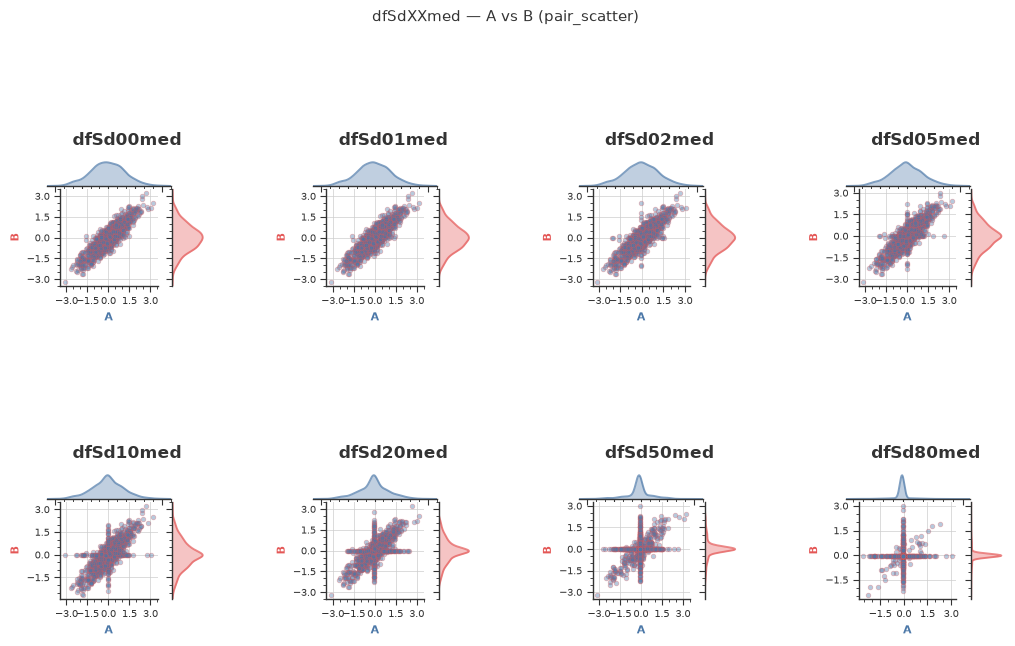

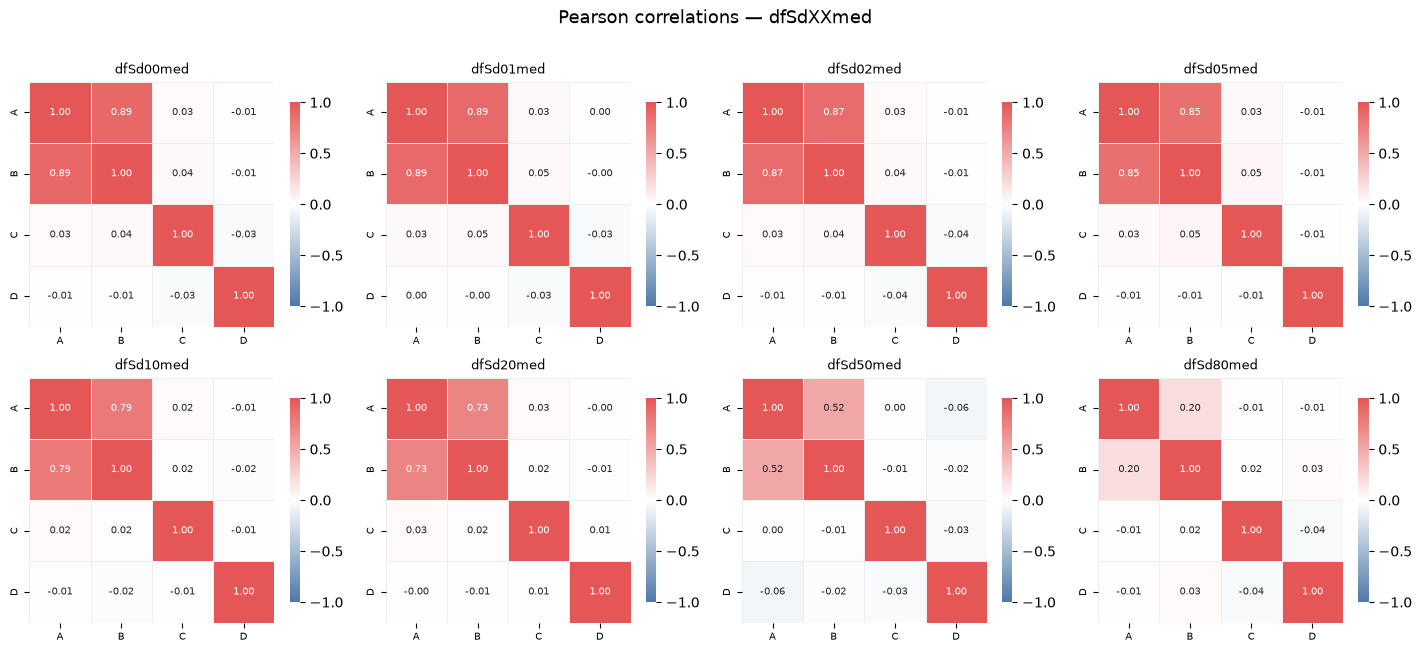


=== dfSd00med Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0294,-0.0090
B,0.8914,1.0000,0.0448,-0.0068
C,0.0294,0.0448,1.0000,-0.0324
D,-0.0090,-0.0068,-0.0324,1.0000



=== dfSd01med Pearson ===


,A,B,C,D
A,1.0000,0.8867,0.0320,0.0003
B,0.8867,1.0000,0.0459,-0.0014
C,0.0320,0.0459,1.0000,-0.0341
D,0.0003,-0.0014,-0.0341,1.0000



=== dfSd02med Pearson ===


...

,A,B,C,D
A,1.0000,0.7256,0.0253,-0.0012
B,0.7256,1.0000,0.0231,-0.0098
C,0.0253,0.0231,1.0000,0.0143
D,-0.0012,-0.0098,0.0143,1.0000



=== dfSd50med Pearson ===


,A,B,C,D
A,1.0000,0.5215,0.0030,-0.0625
B,0.5215,1.0000,-0.0114,-0.0232
C,0.0030,-0.0114,1.0000,-0.0315
D,-0.0625,-0.0232,-0.0315,1.0000



=== dfSd80med Pearson ===


,A,B,C,D
A,1.0000,0.2010,-0.0129,-0.0141
B,0.2010,1.0000,0.0153,0.0278
C,-0.0129,0.0153,1.0000,-0.0431
D,-0.0141,0.0278,-0.0431,1.0000


In [8]:
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

CORR_CMAP = LinearSegmentedColormap.from_list(
    "pair_div",
    ["#4C78A8", "#FFFFFF", "#E45756"],
)


def median_impute(
    data: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """Заполнение NaN медианой соответствующего столбца."""
    out = data.copy()
    for col in columns:
        med = out[col].median(skipna=True)
        out[col] = out[col].fillna(med)
    return out


def median_impute_clones(
    clones: dict[str, pd.DataFrame],
    columns: list[str],
) -> dict[str, pd.DataFrame]:
    """dfSdXX → dfSdXXmed для всех уровней пропусков."""
    return {
        f"{name}med": median_impute(frame, columns)
        for name, frame in clones.items()
    }


def pearson_heatmaps_for_clones(
    clones: dict[str, pd.DataFrame],
    columns: list[str],
    *,
    ncols: int = 4,
    cmap=CORR_CMAP,
    title: str = "Pearson correlations — dfSdXXmed",
) -> dict[str, pd.DataFrame]:
    """Панно heatmap Пирсона: один subplot на каждый импутированный клон."""
    names = list(clones.keys())
    n = len(names)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.6 * ncols, 3.2 * nrows),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=13, y=1.01)

    matrices: dict[str, pd.DataFrame] = {}
    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        corr = clones[name][columns].corr(method="pearson")
        matrices[name] = corr
        sns.heatmap(
            corr,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            cbar_kws={"shrink": 0.75},
            linewidths=0.4,
            linecolor="#EEEEEE",
            annot_kws={"size": 7},
        )
        ax.set_title(name, fontsize=9)
        ax.tick_params(axis="both", labelsize=7)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_axis_off()

    fig.tight_layout()
    display(fig)
    plt.close(fig)
    return matrices


# Импутация медианой всех dfSdXX
dfSd_med_clones = median_impute_clones(dfSd_clones, feature_cols)
globals().update(dfSd_med_clones)

med_summary = pd.DataFrame(
    [
        {
            "name": name,
            "nan_cells_after": int(frame[feature_cols].isna().sum().sum()),
            "A_median": float(frame["A"].median()),
            "B_median": float(frame["B"].median()),
        }
        for name, frame in dfSd_med_clones.items()
    ]
).set_index("name")
display(med_summary.round(4))
print("median clones:", list(dfSd_med_clones.keys()))

# Scatter тем же стилем, что [1.4], по всем *med
med_scatter = pair_scatter_dataset_panel(
    dfSd_med_clones,
    PAIR_XY[0],
    PAIR_XY[1],
    group="class",
    title=f"dfSdXXmed — {PAIR_XY[0]} vs {PAIR_XY[1]} (pair_scatter)",
    ncols=PANEL_NCOLS,
    palette=PAIR_PALETTE,
    point_alpha=0.40,
    density_alpha=0.35,
    show_legend=False,
)
display(med_scatter.fig)
plt.close(med_scatter.fig)

# Корреляции после медианной импутации
pearson_med = pearson_heatmaps_for_clones(
    dfSd_med_clones,
    feature_cols,
    ncols=PANEL_NCOLS,
)

for name, mat in pearson_med.items():
    print(f"\n=== {name} Pearson ===")
    display(mat.round(4))


### [1.8] Multi-method imputation on one `dfSdXX`

Один выбранный `dfSdXX` → med / kNN / регрессия / MICE; сравнение с `dfSd00` (heatmap + 2 scatter-панно).

Pick one missingness clone (`SELECTED_DFSD`). Build filled versions:
- `…med` — column medians
- `…knn` — kNN imputation
- `…reg` — iterative regression (BayesianRidge)
- `…mice` — MICE (`IterativeImputer`)

Then Pearson heatmaps for `dfSd00`, the chosen `dfSdXX`, and each filled
dataset, plus two scatter panels for user pairs (default A+B and C+D).


,nan_cells,complete_rows
name,,
dfSd00,0,1000
dfSd20,800,418
dfSd20med,0,1000
dfSd20knn,0,1000
dfSd20reg,0,1000
dfSd20mice,0,1000


imputed: ['dfSd20med', 'dfSd20knn', 'dfSd20reg', 'dfSd20mice']


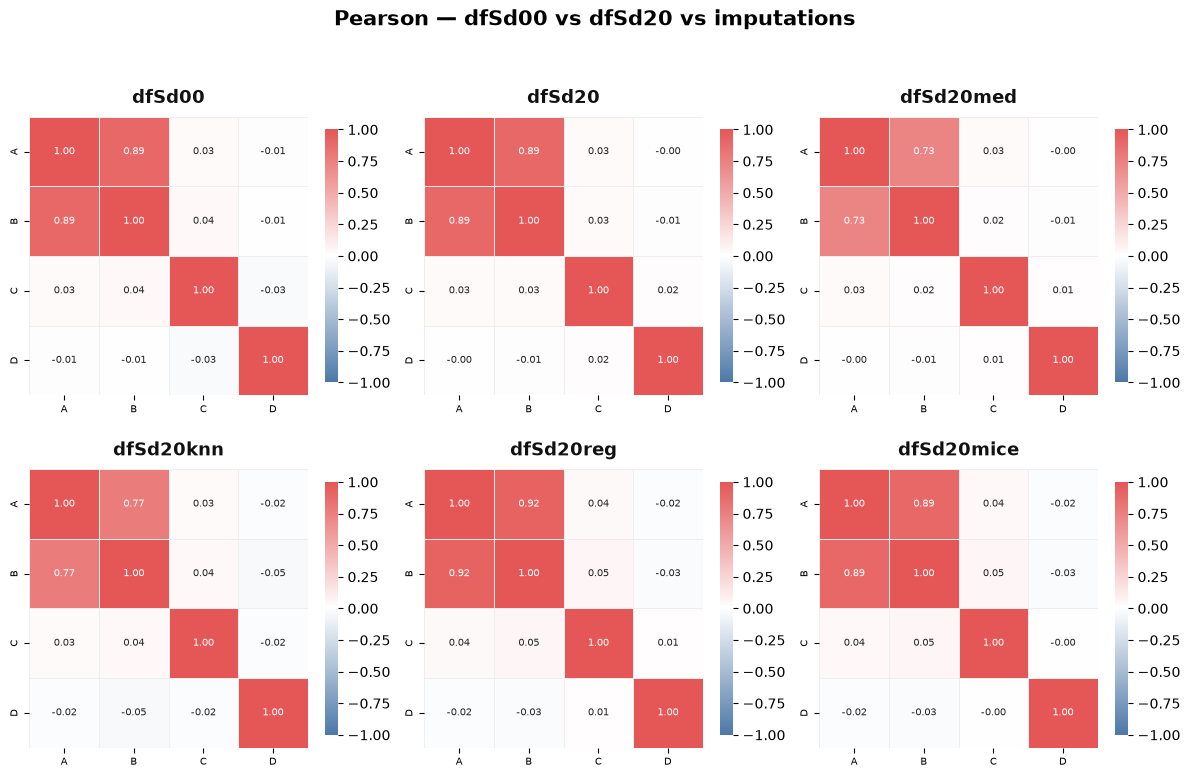

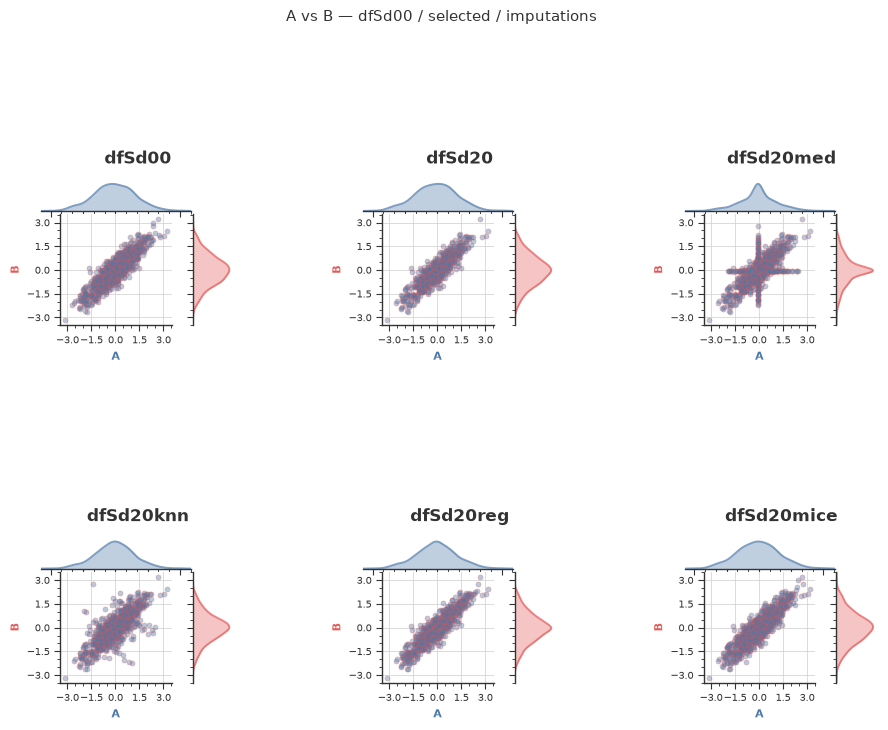

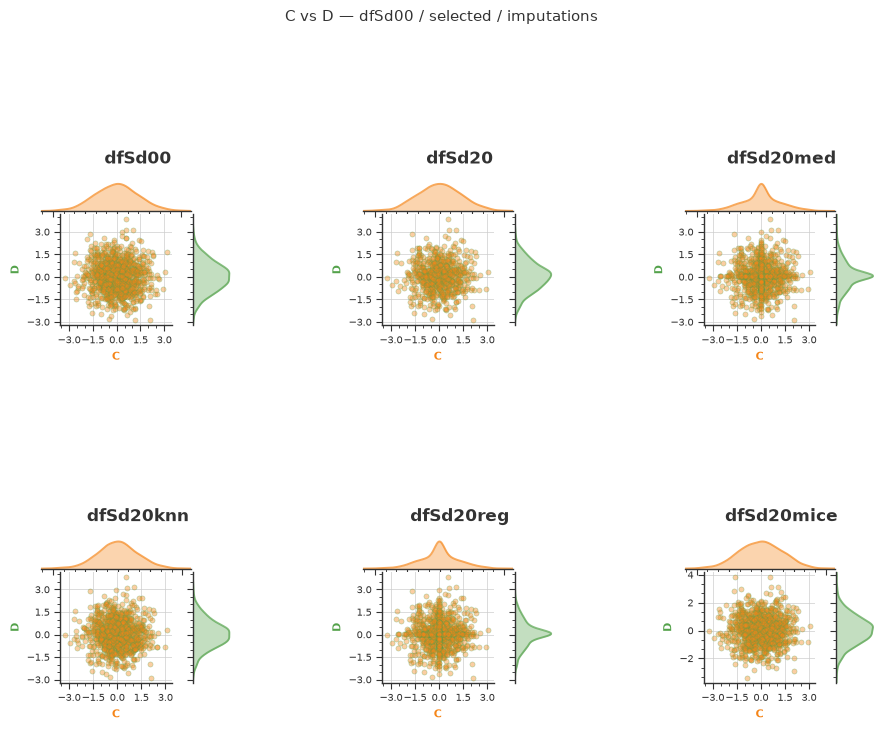


=== dfSd00 Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0294,-0.0090
B,0.8914,1.0000,0.0448,-0.0068
C,0.0294,0.0448,1.0000,-0.0324
D,-0.0090,-0.0068,-0.0324,1.0000



=== dfSd20 Pearson ===


,A,B,C,D
A,1.0000,0.8938,0.0303,-0.0019
B,0.8938,1.0000,0.0306,-0.0119
C,0.0303,0.0306,1.0000,0.0181
D,-0.0019,-0.0119,0.0181,1.0000



=== dfSd20med Pearson ===


...

,A,B,C,D
A,1.0000,0.7735,0.0257,-0.0230
B,0.7735,1.0000,0.0414,-0.0453
C,0.0257,0.0414,1.0000,-0.0216
D,-0.0230,-0.0453,-0.0216,1.0000



=== dfSd20reg Pearson ===


,A,B,C,D
A,1.0000,0.9248,0.0361,-0.0196
B,0.9248,1.0000,0.0500,-0.0290
C,0.0361,0.0500,1.0000,0.0147
D,-0.0196,-0.0290,0.0147,1.0000



=== dfSd20mice Pearson ===


,A,B,C,D
A,1.0000,0.8947,0.0400,-0.0199
B,0.8947,1.0000,0.0504,-0.0301
C,0.0400,0.0504,1.0000,-0.0016
D,-0.0199,-0.0301,-0.0016,1.0000


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge

# --- параметры ---
# Выбранный клон с пропусками и две пары для scatter
SELECTED_DFSD = "dfSd20"  # one of dfSd00 … dfSd80 from [1.6]
PAIR_1 = ("A", "B")
PAIR_2 = ("C", "D")
IMPUTE_SEED = RANDOM_STATE
KNN_NEIGHBORS = 5
PANEL_NCOLS_18 = 3

CORR_CMAP = LinearSegmentedColormap.from_list(
    "pair_div",
    ["#4C78A8", "#FFFFFF", "#E45756"],
)
PAIR_PALETTE = globals().get(
    "PAIR_PALETTE",
    [
        "#4C78A8",
        "#E45756",
        "#F58518",
        "#54A24B",
        "#B279A2",
        "#72B7B2",
        "#ECAE3E",
        "#9D755D",
    ],
)


def _as_feature_frame(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = data.copy()
    # keep non-feature cols (e.g. class) untouched
    return out


# Четыре метода заполнения пропусков
def impute_median(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = data.copy()
    imp = SimpleImputer(strategy="median")
    out[columns] = imp.fit_transform(out[columns])
    return out


def impute_knn(
    data: pd.DataFrame,
    columns: list[str],
    *,
    n_neighbors: int = KNN_NEIGHBORS,
) -> pd.DataFrame:
    out = data.copy()
    imp = KNNImputer(n_neighbors=n_neighbors, weights="distance")
    out[columns] = imp.fit_transform(out[columns])
    return out


def impute_regression(
    data: pd.DataFrame,
    columns: list[str],
    *,
    random_state: int = IMPUTE_SEED,
) -> pd.DataFrame:
    """Итеративная регрессия (без sampling апостериори)."""
    out = data.copy()
    imp = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=10,
        random_state=random_state,
        sample_posterior=False,
    )
    out[columns] = imp.fit_transform(out[columns])
    return out


def impute_mice(
    data: pd.DataFrame,
    columns: list[str],
    *,
    random_state: int = IMPUTE_SEED,
) -> pd.DataFrame:
    """MICE: IterativeImputer + sample_posterior=True."""
    out = data.copy()
    imp = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=random_state,
        sample_posterior=True,
    )
    out[columns] = imp.fit_transform(out[columns])
    return out


IMPUTERS = {
    "med": impute_median,
    "knn": impute_knn,
    "reg": impute_regression,
    "mice": impute_mice,
}


def build_imputed_variants(
    selected: pd.DataFrame,
    selected_name: str,
    columns: list[str],
) -> dict[str, pd.DataFrame]:
    """Строим dfSdXXmed / knn / reg / mice от выбранного клона."""
    variants: dict[str, pd.DataFrame] = {}
    for suffix, fn in IMPUTERS.items():
        name = f"{selected_name}{suffix}"
        variants[name] = fn(selected, columns)
    return variants


def pearson_heatmap_panel(
    datasets: dict[str, pd.DataFrame],
    columns: list[str],
    *,
    ncols: int = PANEL_NCOLS_18,
    title: str = "Pearson correlations",
    cmap=CORR_CMAP,
) -> dict[str, pd.DataFrame]:
    names = list(datasets.keys())
    n = len(names)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.8 * nrows),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.03)
    matrices: dict[str, pd.DataFrame] = {}
    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        # pairwise complete observations (NaNs dropped per pair)
        corr = datasets[name][columns].corr(method="pearson")
        matrices[name] = corr
        sns.heatmap(
            corr,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            cbar_kws={"shrink": 0.75},
            linewidths=0.4,
            linecolor="#EEEEEE",
            annot_kws={"size": 7},
        )
        int(datasets[name][columns].isna().sum().sum())
        ax.set_title(str(name), fontsize=13, fontweight="bold", color="#111111", pad=10)
        ax.tick_params(axis="both", labelsize=7)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_axis_off()
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    return matrices


def scatter_panel_for_pair(
    datasets: dict[str, pd.DataFrame],
    x: str,
    y: str,
    *,
    group: str = "class",
    ncols: int = PANEL_NCOLS_18,
    palette: list[str] | None = None,
    title: str | None = None,
    point_alpha: float = 0.45,
    point_size: float = 12,
) -> None:
    names = list(datasets.keys())
    n = len(names)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    colors = palette or PAIR_PALETTE
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.4 * ncols, 3.2 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    fig.suptitle(title or f"{x} vs {y}", fontsize=13, y=1.01)
    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        frame = datasets[name]
        plot_df = frame[[x, y, group]].dropna()
        classes = list(dict.fromkeys(plot_df[group].astype(str)))
        for j, cls in enumerate(classes):
            mask = plot_df[group].astype(str) == cls
            ax.scatter(
                plot_df.loc[mask, x],
                plot_df.loc[mask, y],
                s=point_size,
                c=colors[j % len(colors)],
                alpha=point_alpha,
                edgecolors="none",
            )
        ax.set_title(f"{name}\nn={len(plot_df)}", fontsize=9)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(True, color="#CCCCCC", lw=0.6)
        ax.set_box_aspect(1)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].set_axis_off()
    fig.tight_layout()
    display(fig)
    plt.close(fig)


# Берём сырой dfSdXX из [1.6] и строим варианты заполнения
if "dfSd_clones" not in globals() or SELECTED_DFSD not in dfSd_clones:
    raise KeyError(
        f"{SELECTED_DFSD!r} missing — run [1.6] first "
        f"(available: {list(globals().get('dfSd_clones', {}))})"
    )

selected_frame = dfSd_clones[SELECTED_DFSD]
dfSd_imputed = build_imputed_variants(selected_frame, SELECTED_DFSD, feature_cols)
globals().update(dfSd_imputed)

# Набор для сравнения: полный dfSd00, сырой клон, все импутации
compare = {
    "dfSd00": dfSd_clones["dfSd00"],
    SELECTED_DFSD: selected_frame,
    **dfSd_imputed,
}

imp_summary = pd.DataFrame(
    [
        {
            "name": name,
            "nan_cells": int(frame[feature_cols].isna().sum().sum()),
            "complete_rows": int((~frame[feature_cols].isna().any(axis=1)).sum()),
        }
        for name, frame in compare.items()
    ]
).set_index("name")
display(imp_summary)
print("imputed:", list(dfSd_imputed.keys()))

# Пирсон по всем вариантам
pearson_18 = pearson_heatmap_panel(
    compare,
    feature_cols,
    ncols=PANEL_NCOLS_18,
    title=f"Pearson — dfSd00 vs {SELECTED_DFSD} vs imputations",
)

# Два scatter-панно для выбранных пар признаков
sc1 = pair_scatter_dataset_panel(
    compare,
    PAIR_1[0],
    PAIR_1[1],
    group="class",
    title=f"{PAIR_1[0]} vs {PAIR_1[1]} — dfSd00 / selected / imputations",
    ncols=PANEL_NCOLS_18,
    palette=PAIR_PALETTE,
    point_alpha=0.40,
    density_alpha=0.35,
)
display(sc1.fig)
plt.close(sc1.fig)
sc2 = pair_scatter_dataset_panel(
    compare,
    PAIR_2[0],
    PAIR_2[1],
    group="class",
    title=f"{PAIR_2[0]} vs {PAIR_2[1]} — dfSd00 / selected / imputations",
    ncols=PANEL_NCOLS_18,
    palette=PAIR_PALETTE,
    point_alpha=0.40,
    density_alpha=0.35,
)
display(sc2.fig)
plt.close(sc2.fig)

for name, mat in pearson_18.items():
    print(f"\n=== {name} Pearson ===")
    display(mat.round(4))


### [1.9] UpSet plots for datasets from [1.8]

(а) паттерны пропусков по признакам; (б) совпадения округлённых значений внутри строки.

For `dfSd00`, the selected `dfSdXX`, and each imputed `dfSdXXname`:

- **(a)** missingness UpSet — sets = features, membership = value is NaN;
  bars show counts for every co-missing pattern
- **(b)** value-coincidence UpSet — sets = features, membership = rounded
  value equals at least one other feature in the same row (intra-row ties);
  bars show counts for every co-coincidence pattern



======== dfSd00 ========
(a) missing cells: 0
skip (all-false membership): dfSd00 — (a) missingness patterns
(b) coincidence flags: 36


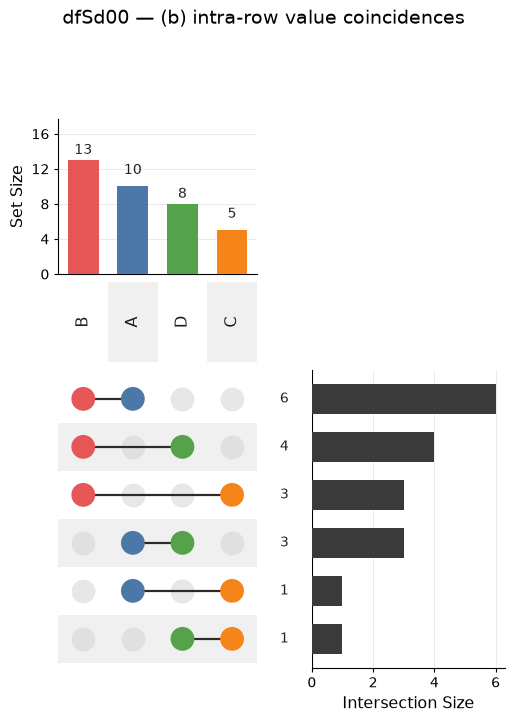


======== dfSd20 ========
(a) missing cells: 800


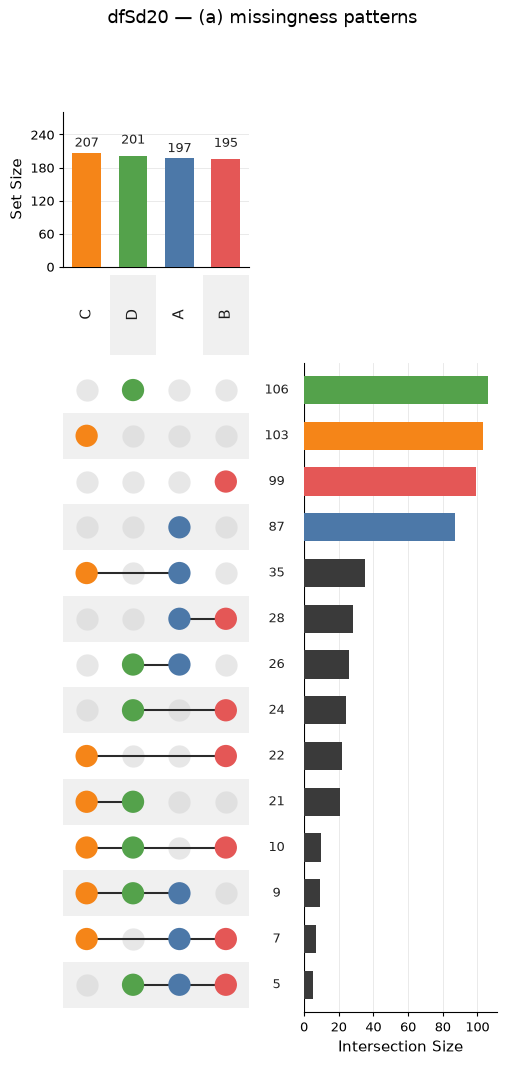

(b) coincidence flags: 28


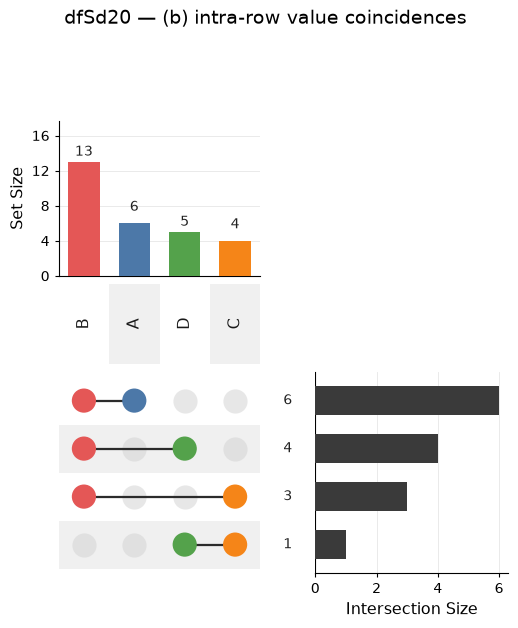


======== dfSd20med ========
(a) missing cells: 0
skip (all-false membership): dfSd20med — (a) missingness patterns
(b) coincidence flags: 125


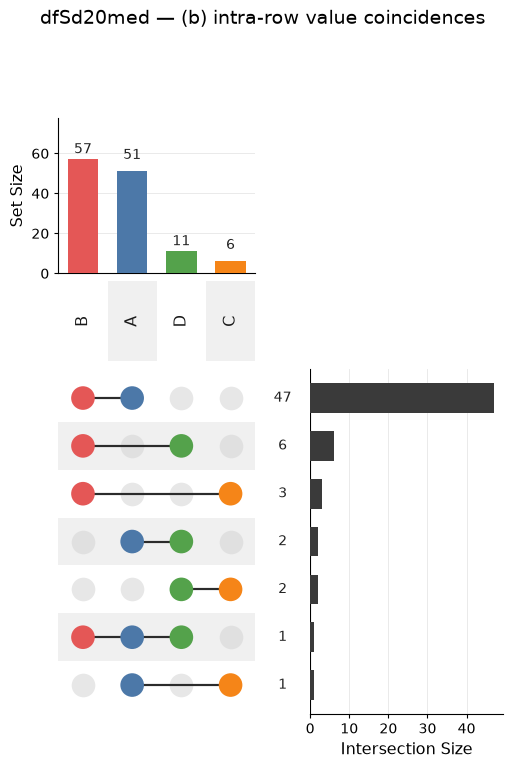


======== dfSd20knn ========
(a) missing cells: 0
skip (all-false membership): dfSd20knn — (a) missingness patterns
(b) coincidence flags: 44


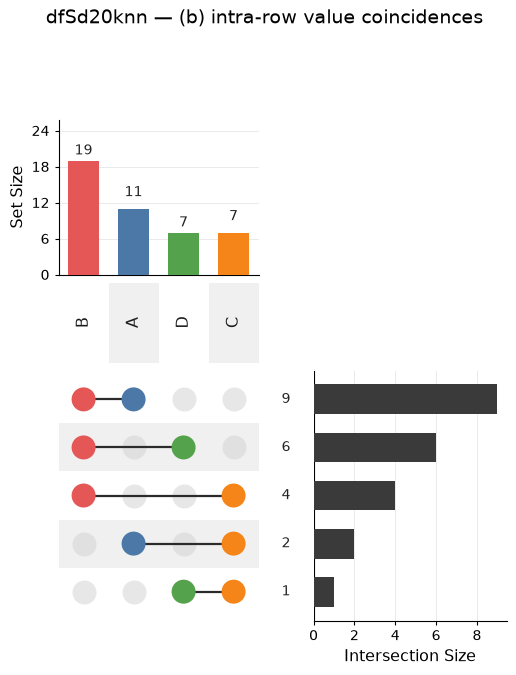


======== dfSd20reg ========
(a) missing cells: 0
skip (all-false membership): dfSd20reg — (a) missingness patterns
(b) coincidence flags: 92


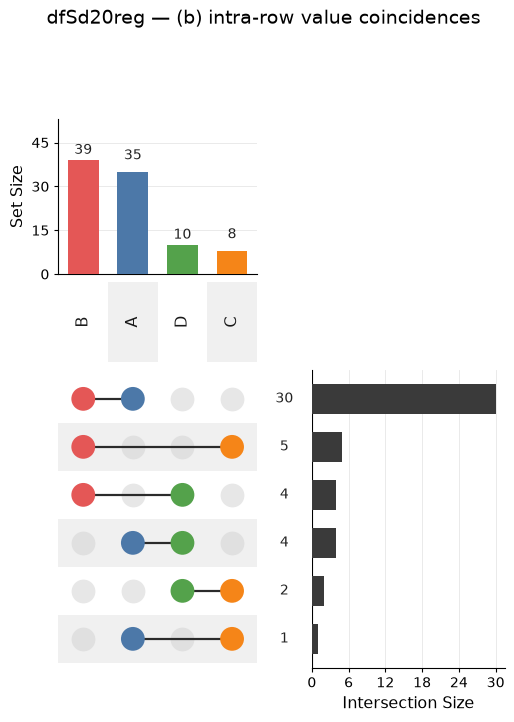


======== dfSd20mice ========
(a) missing cells: 0
skip (all-false membership): dfSd20mice — (a) missingness patterns
(b) coincidence flags: 46


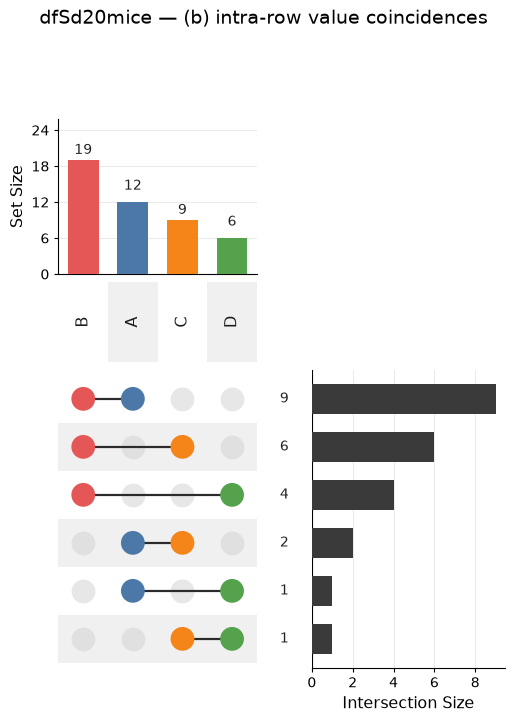

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

UPSET_PALETTE = globals().get(
    "PAIR_PALETTE",
    [
        "#4C78A8",
        "#E45756",
        "#F58518",
        "#54A24B",
        "#B279A2",
        "#72B7B2",
        "#ECAE3E",
        "#9D755D",
    ],
)
COINCIDENCE_DECIMALS = 2  # rounding before testing intra-row value ties


def missingness_membership(
    data: pd.DataFrame, columns: list[str]
) -> pd.DataFrame:
    """Булева матрица: True = в ячейке NaN (для UpSet пропусков)."""
    return data[columns].isna()


def value_coincidence_membership(
    data: pd.DataFrame,
    columns: list[str],
    *,
    decimals: int = COINCIDENCE_DECIMALS,
) -> pd.DataFrame:
    """True, если округлённое значение признака совпало с другим в той же строке."""
    rounded = data[columns].round(decimals)
    mem = pd.DataFrame(False, index=data.index, columns=columns)
    for col in columns:
        for other in columns:
            if other == col:
                continue
            both = rounded[col].notna() & rounded[other].notna()
            mem[col] = mem[col] | (both & (rounded[col] == rounded[other]))
    return mem


# Рисуем UpSet; пустую membership-матрицу пропускаем
def draw_upset_for_membership(
    membership: pd.DataFrame,
    *,
    title: str,
    orientation: str = "vertical",
) -> None:
    if membership.shape[1] == 0:
        print(f"skip (no sets): {title}")
        return
    if not membership.any().any():
        print(f"skip (all-false membership): {title}")
        return
    result = upset_plot(
        membership.astype(bool),
        orientation=orientation,
        title=title,
        sort_sets="size",
        sort_intersections="size",
        max_intersections=None,
        show_set_counts=True,
        show_nan=False,
        intersection_color_mode="exclusive-set",
        set_color=UPSET_PALETTE,
        color_dots_by_set=True,
    )
    display(result.fig)


# Для каждого датасета из [1.8]: (а) пропуски, (б) совпадения значений
def upset_missing_and_coincidence(
    datasets: dict[str, pd.DataFrame],
    columns: list[str],
    *,
    decimals: int = COINCIDENCE_DECIMALS,
) -> None:
    for name, frame in datasets.items():
        print(f"\n======== {name} ========")
        miss = missingness_membership(frame, columns)
        print(f"(a) missing cells: {int(miss.sum().sum())}")
        draw_upset_for_membership(
            miss,
            title=f"{name} — (a) missingness patterns",
        )
        coin = value_coincidence_membership(frame, columns, decimals=decimals)
        print(f"(b) coincidence flags: {int(coin.sum().sum())}")
        draw_upset_for_membership(
            coin,
            title=f"{name} — (b) intra-row value coincidences",
        )


if "compare" not in globals():
    raise KeyError("compare dict missing — run [1.8] first")

upset_missing_and_coincidence(compare, feature_cols)  # compare из ячейки [1.8]


### [1.10] MNAR clone `dfMNAR` + repeat [1.8] / [1.9]


dfMNAR missingness (C/D below median)


,median,nan_cells,nan_frac
C,-0.0075,500,0.5
D,0.0202,500,0.5


,nan_cells,complete_rows
name,,
dfSd00,0,1000
dfMNAR,1000,243
dfMNARmed,0,1000
dfMNARknn,0,1000
dfMNARreg,0,1000
dfMNARmice,0,1000


MNAR imputed: ['dfMNARmed', 'dfMNARknn', 'dfMNARreg', 'dfMNARmice']


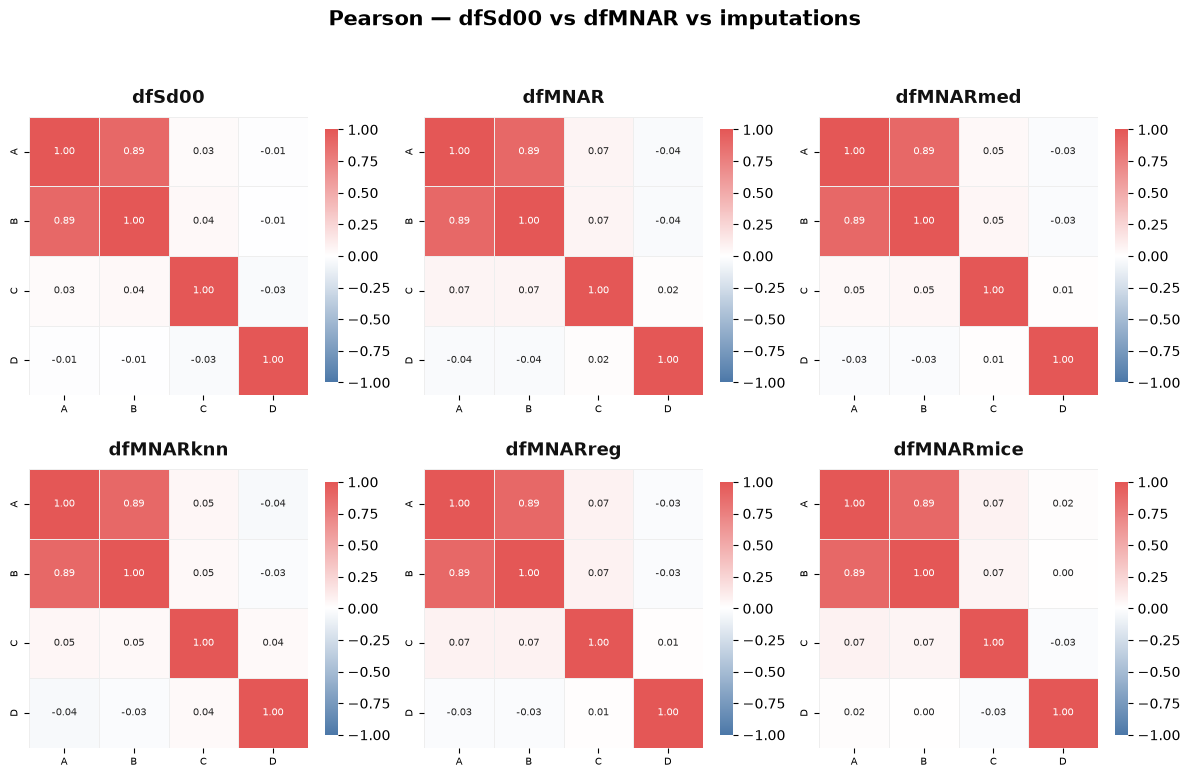

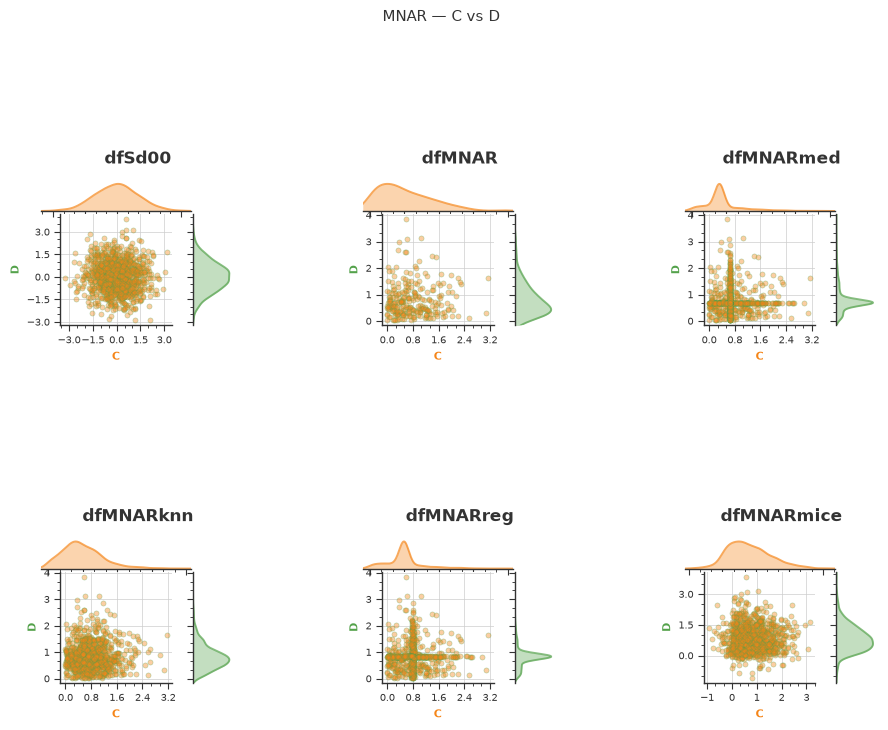


=== [1.9] UpSet for MNAR suite ===

======== dfSd00 ========
(a) missing cells: 0
skip (all-false membership): dfSd00 — (a) missingness patterns
(b) coincidence flags: 36


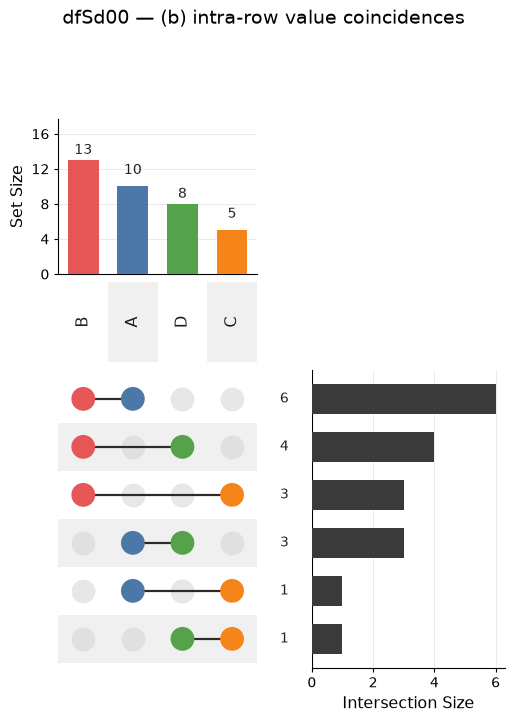


======== dfMNAR ========
(a) missing cells: 1000


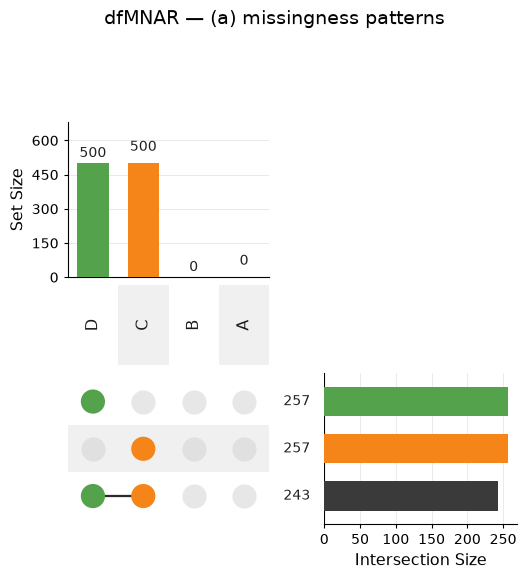

(b) coincidence flags: 30


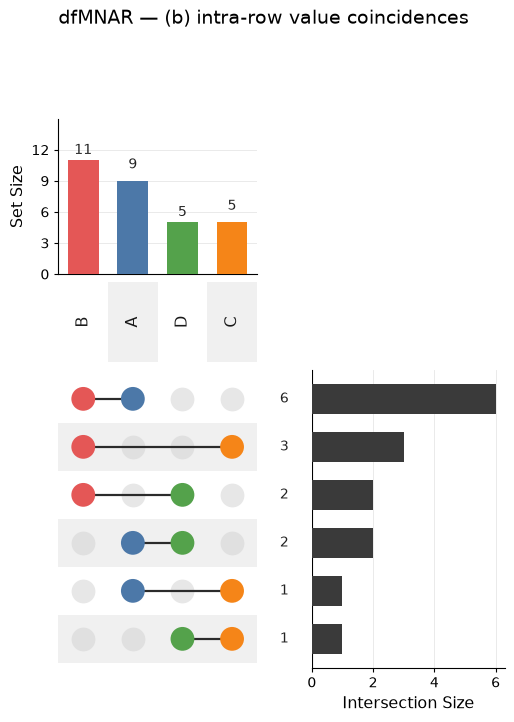


======== dfMNARmed ========
(a) missing cells: 0
skip (all-false membership): dfMNARmed — (a) missingness patterns
(b) coincidence flags: 48


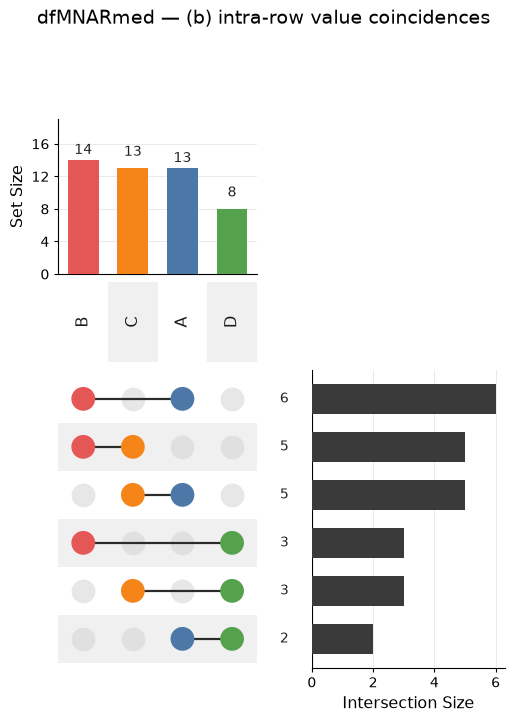


======== dfMNARknn ========
(a) missing cells: 0
skip (all-false membership): dfMNARknn — (a) missingness patterns
(b) coincidence flags: 60


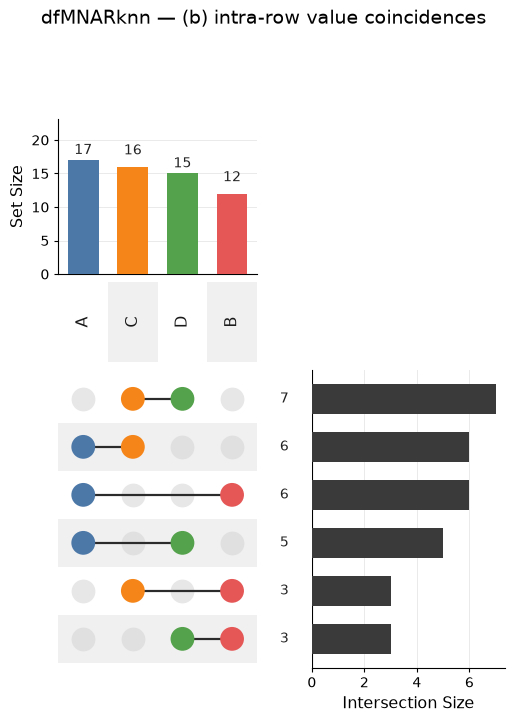


======== dfMNARreg ========
(a) missing cells: 0
skip (all-false membership): dfMNARreg — (a) missingness patterns
(b) coincidence flags: 60


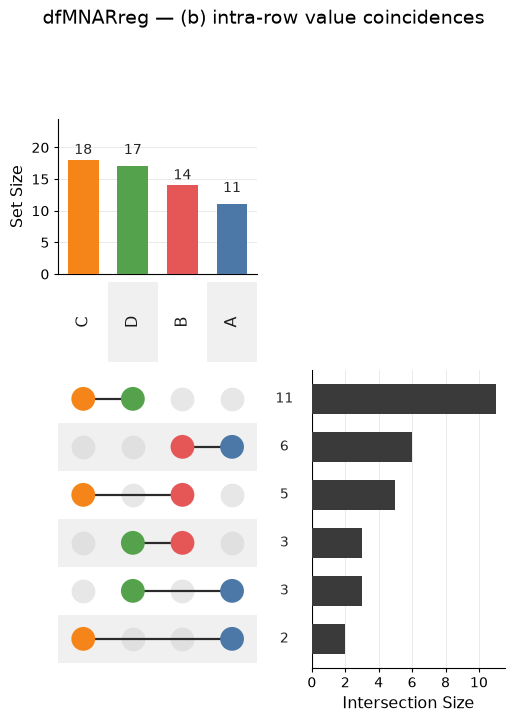


======== dfMNARmice ========
(a) missing cells: 0
skip (all-false membership): dfMNARmice — (a) missingness patterns
(b) coincidence flags: 45


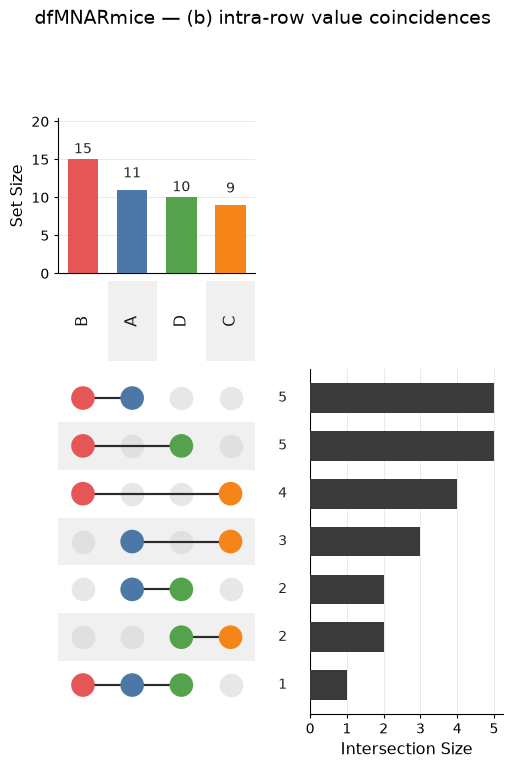


=== dfSd00 Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0294,-0.0090
B,0.8914,1.0000,0.0448,-0.0068
C,0.0294,0.0448,1.0000,-0.0324
D,-0.0090,-0.0068,-0.0324,1.0000



=== dfMNAR Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0670,-0.0352
B,0.8914,1.0000,0.0699,-0.0362
C,0.0670,0.0699,1.0000,0.0178
D,-0.0352,-0.0362,0.0178,1.0000



=== dfMNARmed Pearson ===


...

,A,B,C,D
A,1.0000,0.8914,0.0477,-0.0405
B,0.8914,1.0000,0.0467,-0.0259
C,0.0477,0.0467,1.0000,0.0377
D,-0.0405,-0.0259,0.0377,1.0000



=== dfMNARreg Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0718,-0.0274
B,0.8914,1.0000,0.0740,-0.0281
C,0.0718,0.0740,1.0000,0.0091
D,-0.0274,-0.0281,0.0091,1.0000



=== dfMNARmice Pearson ===


,A,B,C,D
A,1.0000,0.8914,0.0734,0.0161
B,0.8914,1.0000,0.0687,0.0031
C,0.0734,0.0687,1.0000,-0.0292
D,0.0161,0.0031,-0.0292,1.0000


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

MNAR_FEATURES = ("C", "D")


def clone_df_mnar(
    data: pd.DataFrame,
    features: tuple[str, ...] = MNAR_FEATURES,
) -> pd.DataFrame:
    """MNAR: обнуляем C/D, если значение строго меньше медианы признака."""
    out = data.copy()
    for col in features:
        med = out[col].median(skipna=True)
        out.loc[out[col] < med, col] = np.nan
    return out


# Клон с пропусками, зависящими от значения (не MCAR)
dfMNAR = clone_df_mnar(dfS00, MNAR_FEATURES)

mnar_info = pd.DataFrame(
    {
        "median": [dfS00[c].median() for c in MNAR_FEATURES],
        "nan_cells": [int(dfMNAR[c].isna().sum()) for c in MNAR_FEATURES],
        "nan_frac": [float(dfMNAR[c].isna().mean()) for c in MNAR_FEATURES],
    },
    index=list(MNAR_FEATURES),
)
print("dfMNAR missingness (C/D below median)")
display(mnar_info.round(4))

# Повторяем пайплайн [1.8] на dfMNAR (нужны функции из ячейки 1.8)
required_1_8 = [
    "build_imputed_variants",
    "pearson_heatmap_panel",
    "PAIR_2",
    "PANEL_NCOLS_18",
    "PAIR_PALETTE",
]
missing_helpers = [n for n in required_1_8 if n not in globals()]
if missing_helpers:
    raise KeyError(
        f"Missing {missing_helpers} — run [1.8] cell first so helpers exist"
    )

MNAR_BASE = "dfMNAR"
dfMNAR_imputed = build_imputed_variants(dfMNAR, MNAR_BASE, feature_cols)
globals().update(dfMNAR_imputed)

# baseline complete sample as dfSd00 when available, else raw dfS00
baseline = (
    dfSd_clones["dfSd00"]
    if "dfSd_clones" in globals() and "dfSd00" in dfSd_clones
    else dfS00
)
compare_mnar = {
    "dfSd00": baseline,
    MNAR_BASE: dfMNAR,
    **dfMNAR_imputed,
}

mnar_summary = pd.DataFrame(
    [
        {
            "name": name,
            "nan_cells": int(frame[feature_cols].isna().sum().sum()),
            "complete_rows": int((~frame[feature_cols].isna().any(axis=1)).sum()),
        }
        for name, frame in compare_mnar.items()
    ]
).set_index("name")
display(mnar_summary)
print("MNAR imputed:", list(dfMNAR_imputed.keys()))

# Корреляции и scatter (только пара C+D — на неё действует MNAR)
pearson_mnar = pearson_heatmap_panel(
    compare_mnar,
    feature_cols,
    ncols=PANEL_NCOLS_18,
    title="Pearson — dfSd00 vs dfMNAR vs imputations",
)

sc2_mnar = pair_scatter_dataset_panel(
    compare_mnar,
    PAIR_2[0],
    PAIR_2[1],
    group="class",
    title=f"MNAR — {PAIR_2[0]} vs {PAIR_2[1]}",
    ncols=PANEL_NCOLS_18,
    palette=PAIR_PALETTE,
    point_alpha=0.40,
    density_alpha=0.35,
)
display(sc2_mnar.fig)
plt.close(sc2_mnar.fig)

# UpSet как в [1.9] для MNAR-набора
if "upset_missing_and_coincidence" not in globals():
    raise KeyError("upset_missing_and_coincidence missing — run [1.9] first")

print("\n=== [1.9] UpSet for MNAR suite ===")
upset_missing_and_coincidence(compare_mnar, feature_cols)

for name, mat in pearson_mnar.items():
    print(f"\n=== {name} Pearson ===")
    display(mat.round(4))
